In [1]:
from entsoe import EntsoePandasClient
from entsoe.exceptions import NoMatchingDataError, PaginationError
from requests.exceptions import HTTPError

import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from pathlib import Path

API_KEY = "1206c24a-2fb6-4ec3-a47f-0e1be10dacd4"
client = EntsoePandasClient(api_key= API_KEY)

In [2]:
start = pd.Timestamp("2024-01-01", tz="Europe/Brussels")
end   = pd.Timestamp("2024-12-31", tz="Europe/Brussels")

country_code = "NL"

process_type =  "A16" # A16 = Realised; A60 = Scheduled activation mFRR; A61 = Direct activation mFRR; A68 = Local Selection aFRR
business_type = "A96"  # A95 = Frequency containment reserve; A96 = Automatic frequency restoration reserve; A97 = Manual frequency restoration reserve; A98 = Replacement reserve

In [3]:
df = client.query_activated_balancing_energy_prices(country_code, start=start, end=end, process_type=process_type, psr_type=None, business_type=business_type, standard_market_product=None, original_market_product=None)

In [4]:
print(df.head())

                          Direction  Price ReserveType
2024-01-01 00:00:00+01:00        Up  83.22        aFRR
2024-01-01 00:00:00+01:00      Down -46.72        aFRR
2024-01-01 00:15:00+01:00      Down   0.00        aFRR
2024-01-01 00:15:00+01:00        Up  76.91        aFRR
2024-01-01 00:30:00+01:00        Up  66.91        aFRR


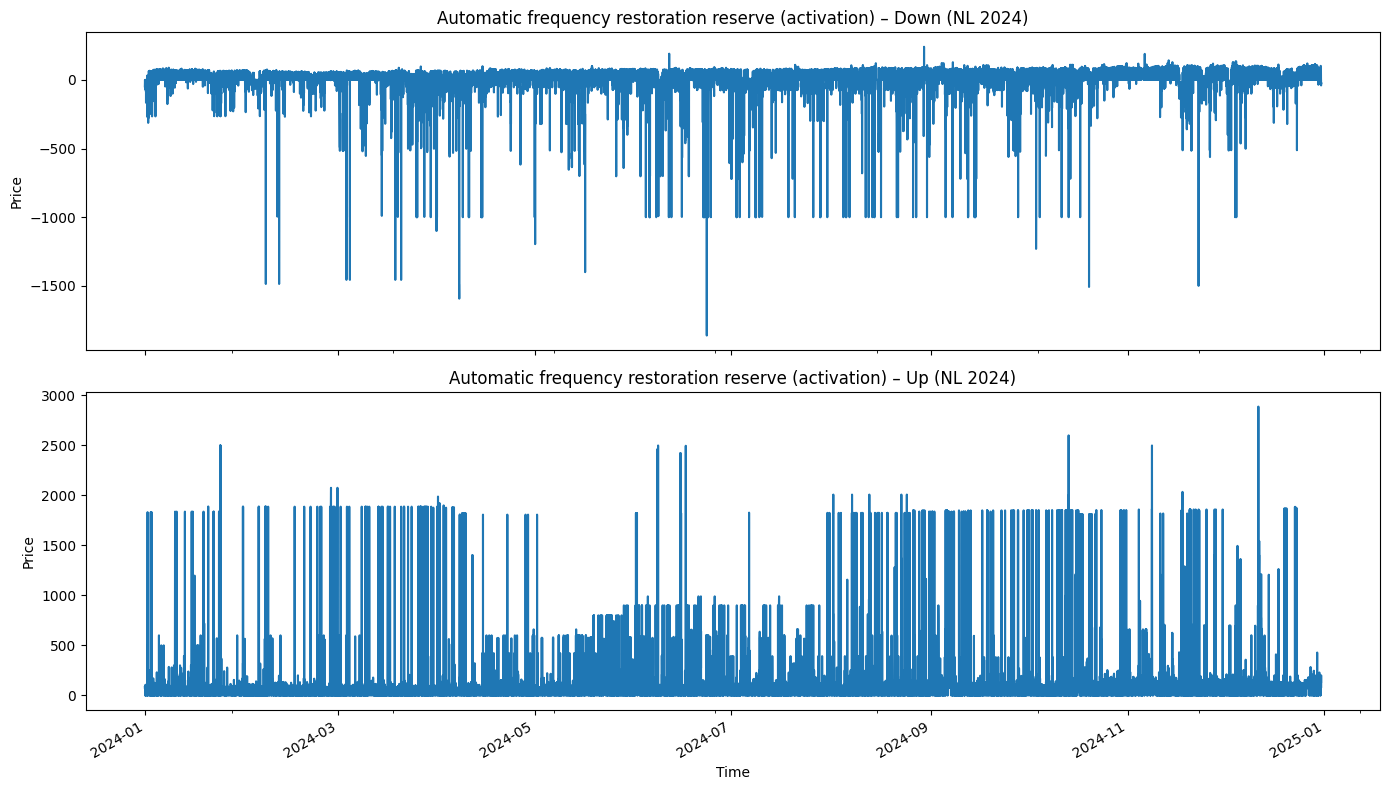

In [6]:
df_plot = df.pivot_table(
    index=df.index,
    columns="Direction",
    values="Price"
)

# Ensure the columns are exactly 'Down' and 'Up'
df_plot = df_plot[["Down", "Up"]]  # will error if one is missing

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 8))

df_plot["Down"].plot(ax=ax1)
ax1.set_title("Automatic frequency restoration reserve (activation) – Down (NL 2024)")
ax1.set_ylabel("Price")

df_plot["Up"].plot(ax=ax2)
ax2.set_title("Automatic frequency restoration reserve (activation) – Up (NL 2024)")
ax2.set_ylabel("Price")
ax2.set_xlabel("Time")

plt.tight_layout()
plt.show()

In [5]:
df = (
    df
    .rename_axis("datetime")  # give the index a name
    .reset_index()            # move it to a normal column
)

data_folder = Path.cwd()/"CSV"
df.to_csv(data_folder/"activated_aFRR_NL.csv", index=False)
